# InstanceGenerator marginal distribution checks

This notebook compares synthetic instances generated by `InstanceGenerator` against empirical marginal distributions by intermediary:

- daily pickup counts
- pickup quantities
- farmer–intermediary Euclidean distances
- optional daily road-tour distance diagnostics

The intent is not to prove joint distributional fit; it is a clean EDA check that the generator reproduces key one-dimensional empirical marginals.


In [1]:
from pathlib import Path
import sys
from functools import lru_cache

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox

from instance_generator import InstanceGenerator

sns.set_theme(style="whitegrid", context="notebook")


## Configuration


In [2]:
# Paths are relative to the notebook location.
FARMERS_FULL_PATH = "../data/farmers.csv"
FARMERS_14_PATH = "../data/farmers_2.csv"
INTS_PATH = "../data/ints.csv"
GRAPH_PATH = "../data/graph_0-14960_00_new.pickle"

PLOTS_DIR = Path("../results/ig_dev_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Synthetic panel size.
N_GENERATED_DAYS = 100
SEED = 10

# Toggle expensive road-distance diagnostics.
RUN_ROAD_TSP = True


In [18]:
def save_fig(fig, filename, dpi=200):
    out_path = PLOTS_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved {out_path}")


def standardize_int_order(data, value_col=None):
    if value_col is None:
        return sorted(data["int_id_anon"].dropna().unique())
    return (
        data.groupby("int_id_anon")[value_col]
        .median()
        .sort_values()
        .index
        .tolist()
    )


def facet_hist_compare_by_intermediary(
    data,
    x,
    *,
    title,
    xlabel=None,
    ylabel="Percent",
    bins=None,
    discrete=False,
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=None,
    ylim=None,
    xticks=None,
    order=None,
):
    plot_df = data.copy()
    plot_df = plot_df.dropna(subset=["int_id_anon", "source", x])
    plot_df["int_id_anon"] = plot_df["int_id_anon"].astype(str)

    if order is None:
        order = standardize_int_order(plot_df)

    g = sns.displot(
        data=plot_df,
        x=x,
        hue="source",
        col="int_id_anon",
        col_order=order,
        col_wrap=col_wrap,
        bins=bins,
        discrete=discrete,
        stat="percent",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.28,
        height=height,
        aspect=aspect,
        facet_kws={"sharex": True, "sharey": True},
    )

    g.set_titles("{col_name}", size=10)
    g.set_axis_labels(xlabel or x, ylabel)

    for ax in g.axes.flatten():
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.tick_params(labelbottom=True)

        if xticks is not None:
            ax.set_xticks(xticks)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

    g.figure.suptitle(title, fontsize=15, y=1.03)
    g.figure.tight_layout()
    return g


def summarize_by_source(data, metric):
    return (
        data.dropna(subset=[metric])
        .groupby(["int_id_anon", "source"])[metric]
        .agg(n="count", mean="mean", median="median", std="std")
        .reset_index()
        .sort_values(["int_id_anon", "source"])
    )


## Initialize generator and fix generated intermediaries to empirical intermediary identities

For this validation notebook, each synthetic intermediary is assigned the same location and type as one empirical intermediary. This makes intermediary-by-intermediary marginal comparisons interpretable.


In [ ]:
ig = InstanceGenerator(
    FARMERS_FULL_PATH,
    FARMERS_14_PATH,
    INTS_PATH,
    GRAPH_PATH,
)

ig.ints = {}
for _, row in ig.ints_df.iterrows():
    int_id = row["int_id"]
    ig.ints[int_id] = {
        "xy": (row["int_x"], row["int_y"]),
        "ll": (row["int_lat"], row["int_lon"]),
        "type": int_id,
    }

INT_ORDER = sorted(ig.ints.keys())
print(f"Loaded {len(INT_ORDER)} intermediary types:")
print(INT_ORDER)


## Generate synthetic panel


In [ ]:
def instance_to_df(instance, generator):
    """Convert an InstanceGenerator output dictionary into one farmer-level DataFrame."""
    farmers = pd.DataFrame(instance["farmers"]).copy()
    intermediaries = pd.DataFrame(instance["intermediaries"]).copy()

    if farmers.empty:
        return pd.DataFrame()

    farmers = farmers.rename(columns={"id": "farmer_id", "intermediary": "int_id"})
    farmers["farmer_lat"] = farmers["location"].apply(lambda loc: loc[0])
    farmers["farmer_lon"] = farmers["location"].apply(lambda loc: loc[1])
    farmers["farmer_x"], farmers["farmer_y"] = generator.ll_to_xy.transform(
        farmers["farmer_lon"].to_numpy(),
        farmers["farmer_lat"].to_numpy(),
    )
    farmers = farmers.drop(columns=["location"])

    intermediaries = intermediaries.rename(columns={"id": "int_id"})
    intermediaries["int_lat"] = intermediaries["location"].apply(lambda loc: loc[0])
    intermediaries["int_lon"] = intermediaries["location"].apply(lambda loc: loc[1])
    intermediaries["int_x"], intermediaries["int_y"] = generator.ll_to_xy.transform(
        intermediaries["int_lon"].to_numpy(),
        intermediaries["int_lat"].to_numpy(),
    )
    intermediaries = intermediaries.drop(columns=["location", "routes"])

    out = farmers.merge(intermediaries, on="int_id", how="left", validate="many_to_one")
    out["distance_m"] = np.sqrt(
        (out["farmer_x"] - out["int_x"]) ** 2
        + (out["farmer_y"] - out["int_y"]) ** 2
    )
    out["distance_km"] = out["distance_m"] / 1000
    return out


def generate_synthetic_panel(generator, n_days=N_GENERATED_DAYS):
    all_days = []
    for day_seed in range(n_days):
        instance = generator.gen_instance(
            instance_id=f"generated_{day_seed}",
            seed=day_seed,
            plot=False,
            write=False,
        )
        day_df = instance_to_df(instance, generator)
        day_df["date"] = day_seed
        all_days.append(day_df)

    return (
        pd.concat(all_days, ignore_index=True)
        .sort_values(["int_id", "date", "farmer_id"])
        .reset_index(drop=True)
    )


df_gen = generate_synthetic_panel(ig, N_GENERATED_DAYS)
print(df_gen.shape)
df_gen.head()


In [ ]:
# Build a stable anonymization map
int_ids = sorted(df_gen["int_id"].dropna().unique())

int_name_map = {
    int_id: f"Intermediary {i+1}"
    for i, int_id in enumerate(int_ids)
}

# Apply to dataframe
df_gen["int_id_anon"] = df_gen["int_id"].map(int_name_map)

## Network size diagnostic

This is a quick check of how many unique generated farmer locations appear for each intermediary across generated days.


Saved ../results/ig_dev_plots/generated_network_size_by_intermediary.png


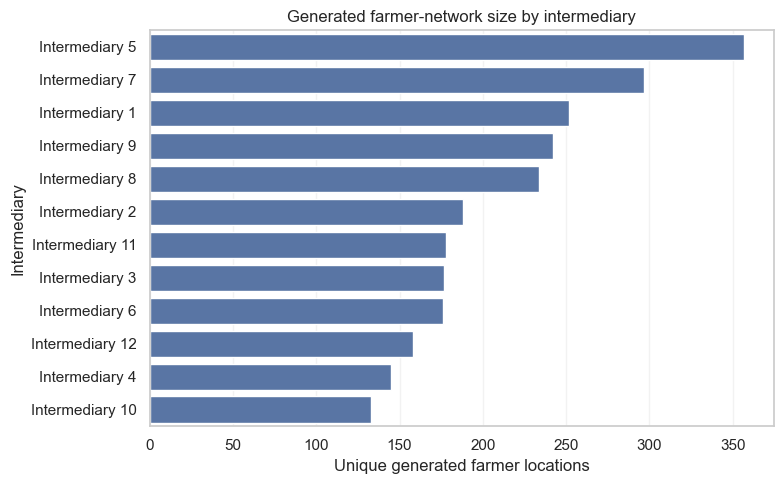

In [8]:
network_size = (
    df_gen.drop_duplicates(["int_id_anon", "farmer_x", "farmer_y"])
    .groupby("int_id_anon")
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=network_size.values, y=network_size.index, ax=ax)
ax.set_xlabel("Unique generated farmer locations")
ax.set_ylabel("Intermediary")
ax.set_title("Generated farmer-network size by intermediary")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
save_fig(fig, "generated_network_size_by_intermediary.png")
plt.show()


## Marginal check 1: daily pickup counts


In [9]:
ig.farmers_14_df["int_id_anon"] = ig.farmers_14_df["int_id"].map(int_name_map)
ig.farmers_full_df["int_id_anon"] = ig.farmers_full_df["int_id"].map(int_name_map)

In [ ]:
df_gen

         int_id_anon        date  count      source
0     Intermediary 1  2020-08-27      3  Historical
1     Intermediary 1  2020-08-29      2  Historical
2     Intermediary 1  2020-08-31      3  Historical
3     Intermediary 1  2020-09-01      1  Historical
4     Intermediary 1  2020-09-02      2  Historical
...              ...         ...    ...         ...
1323  Intermediary 9          95      3   Generated
1324  Intermediary 9          96      3   Generated
1325  Intermediary 9          97      2   Generated
1326  Intermediary 9          98      7   Generated
1327  Intermediary 9          99      4   Generated

[1328 rows x 4 columns]
Saved ../results/ig_dev_plots/daily_pickup_count_hist_vs_generated.png


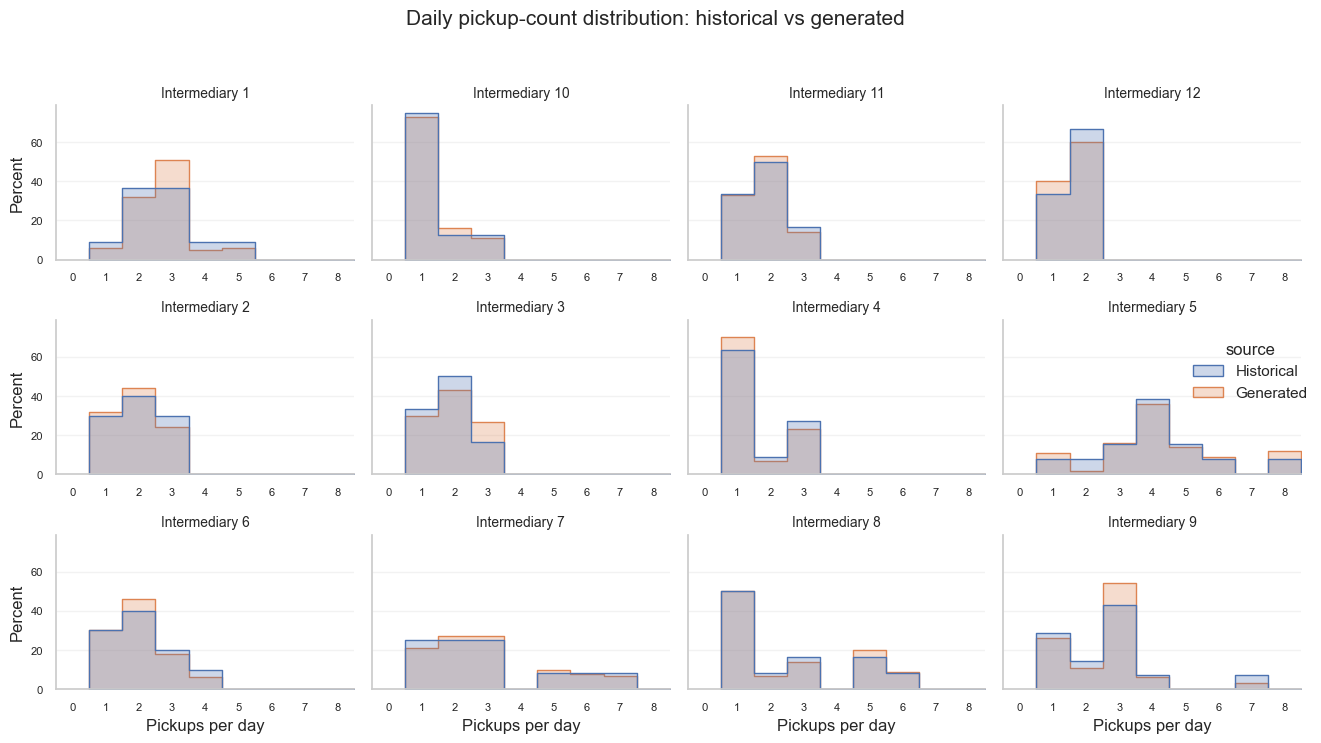

,int_id_anon,source,n,mean,median,std
0,Intermediary 1,Generated,100,2.730000,3.0,0.885974
1,Intermediary 1,Historical,11,2.727273,3.0,1.103713
2,Intermediary 10,Generated,100,1.380000,1.0,0.678382
3,Intermediary 10,Historical,8,1.375000,1.0,0.744024
4,Intermediary 11,Generated,100,1.810000,2.0,0.662029
5,Intermediary 11,Historical,12,1.833333,2.0,0.717741
6,Intermediary 12,Generated,100,1.600000,2.0,0.492366
7,Intermediary 12,Historical,3,1.666667,2.0,0.577350
8,Intermediary 2,Generated,100,1.920000,2.0,0.747791
9,Intermediary 2,Historical,10,2.000000,2.0,0.816497


In [21]:
pickups_hist = (
    ig.farmers_14_df
    .groupby(["int_id_anon", "date"])
    .size()
    .reset_index(name="count")
)
pickups_hist["source"] = "Historical"

pickups_gen = (
    df_gen
    .groupby(["int_id_anon", "date"])
    .size()
    .reset_index(name="count")
)
pickups_gen["source"] = "Generated"

pickups_combined = pd.concat([pickups_hist, pickups_gen], ignore_index=True)

max_count = int(pickups_combined["count"].max())
count_bins = np.arange(-0.5, max_count + 1.5, 1)
count_xticks = np.arange(0, max_count + 1, 1)

print(pickups_combined)

g = facet_hist_compare_by_intermediary(
    pickups_combined,
    "count",
    title="Daily pickup-count distribution: historical vs generated",
    xlabel="Pickups per day",
    bins=count_bins,
    discrete=True,
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=(-0.5, max_count + 0.5),
    xticks=count_xticks,
)
save_fig(g.figure, "daily_pickup_count_hist_vs_generated.png")
plt.show()

summarize_by_source(pickups_combined, "count").head(20)


## Marginal check 2: pickup quantities


Saved ../results/ig_dev_plots/pickup_quantity_hist_vs_generated.png


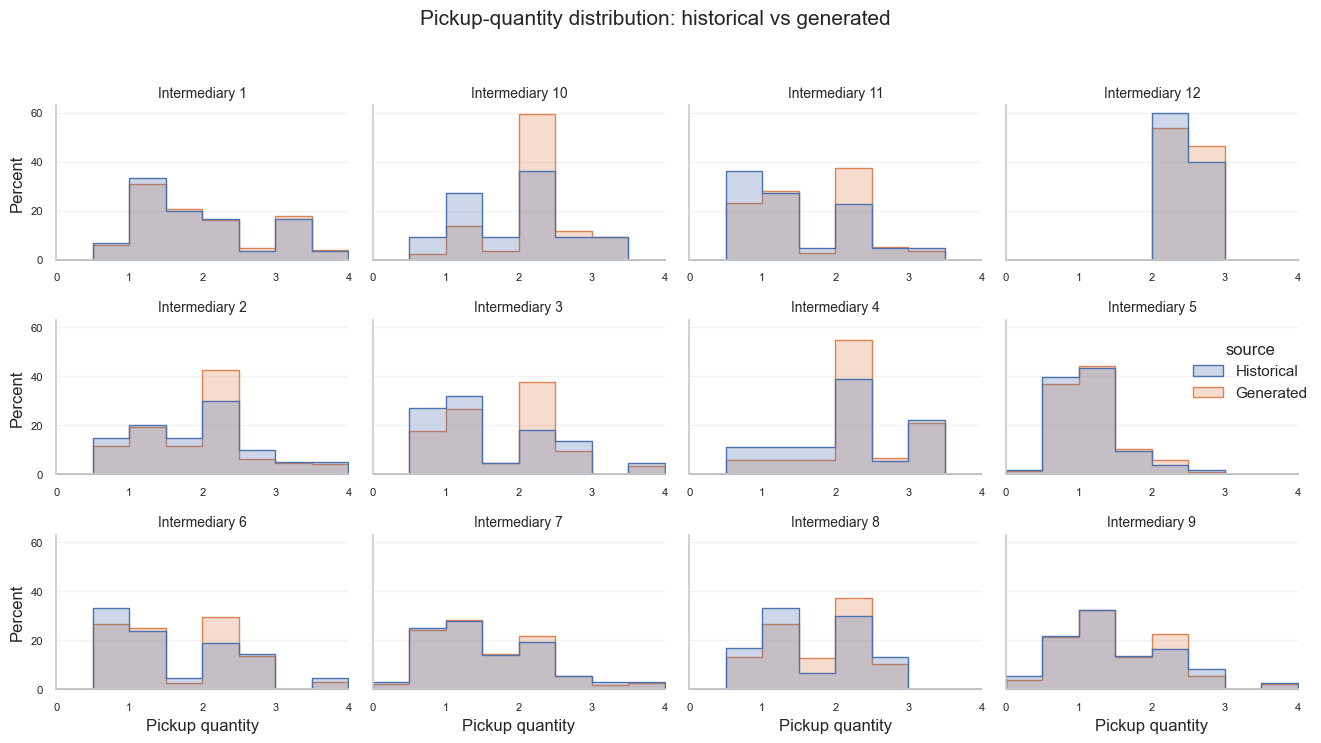

,int_id_anon,source,n,mean,median,std
0,Intermediary 1,Generated,273,1.917949,1.70,0.813946
1,Intermediary 1,Historical,30,1.853333,1.60,0.802897
2,Intermediary 10,Generated,138,2.013043,2.00,0.581067
3,Intermediary 10,Historical,11,1.754545,2.00,0.751483
4,Intermediary 11,Generated,181,1.508287,1.30,0.678632
5,Intermediary 11,Historical,22,1.345455,1.00,0.717620
6,Intermediary 12,Generated,160,2.553750,2.40,0.351795
7,Intermediary 12,Historical,5,2.520000,2.40,0.383406
8,Intermediary 2,Generated,192,1.868750,2.00,0.706042
9,Intermediary 2,Historical,20,1.850000,1.95,0.796373


In [23]:
quantity_hist = ig.farmers_14_df[["int_id_anon", "quantity"]].copy()
quantity_hist["source"] = "Historical"

quantity_gen = df_gen[["int_id_anon", "quantity"]].copy()
quantity_gen["source"] = "Generated"

quantity_combined = pd.concat([quantity_hist, quantity_gen], ignore_index=True)

max_q = float(quantity_combined["quantity"].max())
quantity_bins = np.arange(0, np.ceil(max_q * 2) / 2 + 0.5, 0.5)
quantity_xticks = np.arange(0, quantity_bins.max() + 0.5, 1.0)

g = facet_hist_compare_by_intermediary(
    quantity_combined,
    "quantity",
    title="Pickup-quantity distribution: historical vs generated",
    xlabel="Pickup quantity",
    bins=quantity_bins,
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=(0, quantity_bins.max()),
    xticks=quantity_xticks,
)
save_fig(g.figure, "pickup_quantity_hist_vs_generated.png")
plt.show()

summarize_by_source(quantity_combined, "quantity").head(20)


## Marginal check 3: farmer–intermediary Euclidean distance

The generator samples farmer locations using intermediary-specific empirical distance distributions. This diagnostic compares empirical farmer-intermediary distances against generated Euclidean distances.


Saved ../results/ig_dev_plots/farmer_intermediary_distance_hist_vs_generated.png


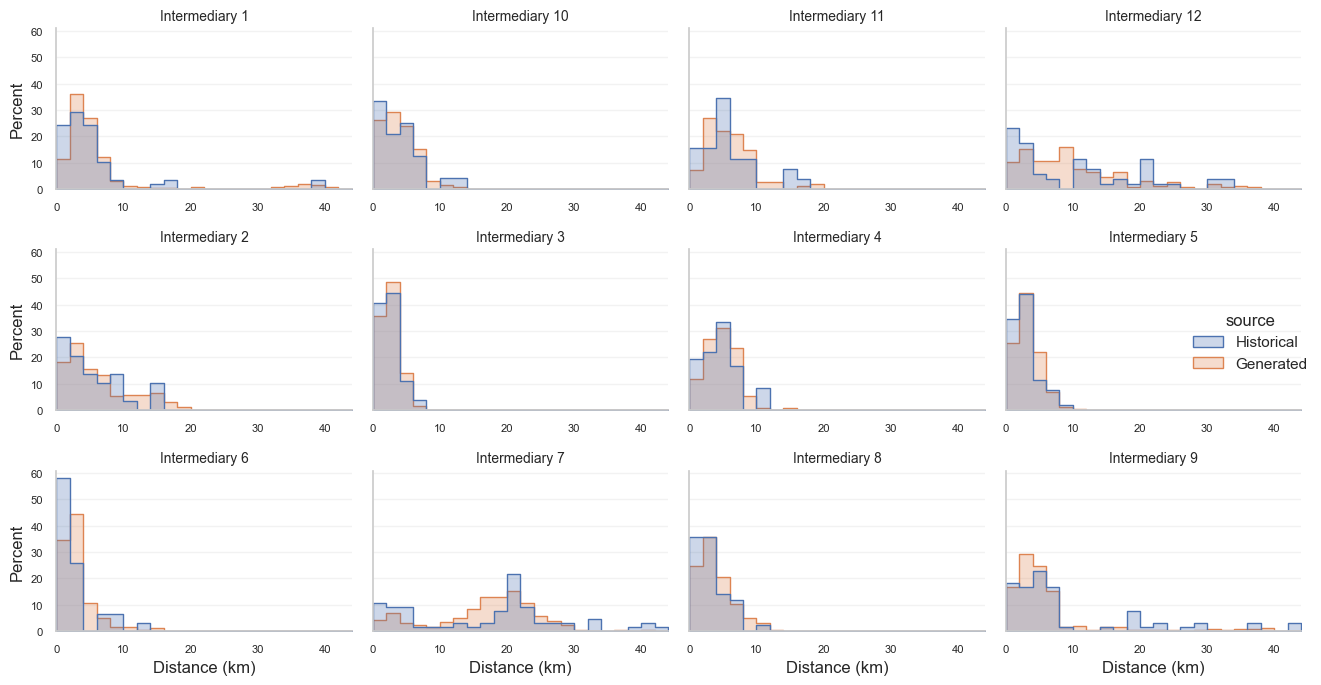

,int_id_anon,source,n,mean,median,std
0,Intermediary 1,Generated,252,6.589269,4.154895,8.480084
1,Intermediary 1,Historical,58,5.612946,3.868591,7.114286
2,Intermediary 10,Generated,133,3.958958,3.687460,2.413797
3,Intermediary 10,Historical,24,3.994424,2.971062,3.088962
4,Intermediary 11,Generated,178,5.931178,5.468792,3.518927
5,Intermediary 11,Historical,26,5.778720,4.674989,4.210322
6,Intermediary 12,Generated,158,10.008137,8.418534,7.817022
7,Intermediary 12,Historical,53,11.449492,10.985045,10.898834
8,Intermediary 2,Generated,188,6.221506,4.583942,4.754187
9,Intermediary 2,Historical,29,5.494614,4.658470,4.261390


In [29]:
distance_hist = (
    ig.farmers_full_df
    .drop_duplicates(["int_id_anon", "farmer_x", "farmer_y"])
    [["int_id_anon", "farmer_x", "farmer_y", "distance"]]
    .copy()
)
distance_hist["distance_km"] = distance_hist["distance"] / 1000
if distance_hist["distance_km"].median() > 200:
    # Safety fallback in case the source column is already kilometers.
    distance_hist["distance_km"] = distance_hist["distance"]
distance_hist["source"] = "Historical"

distance_gen = (
    df_gen
    .drop_duplicates(["int_id_anon", "farmer_x", "farmer_y"])
    [["int_id_anon", "farmer_x", "farmer_y", "distance_km"]]
    .copy()
)
distance_gen["source"] = "Generated"

distance_combined = pd.concat(
    [distance_hist[["int_id_anon", "distance_km", "source"]], distance_gen[["int_id_anon", "distance_km", "source"]]],
    ignore_index=True,
)

max_dist = float(distance_combined["distance_km"].quantile(0.995))
distance_bins = np.arange(0, np.ceil(max_dist / 2) * 2 + 2, 2)
distance_xticks = np.arange(0, distance_bins.max() + 1, 10)

g = facet_hist_compare_by_intermediary(
    distance_combined,
    "distance_km",
    title=None,
    # title="Farmer–intermediary distance distribution: historical vs generated",
    xlabel="Distance (km)",
    bins=distance_bins,
    col_wrap=4,
    height=2.4,
    aspect=1.25,
    xlim=(0, distance_bins.max()),
    xticks=distance_xticks,
)
save_fig(g.figure, "farmer_intermediary_distance_hist_vs_generated.png")
plt.show()

summarize_by_source(distance_combined, "distance_km").head(20)


## Optional diagnostic: daily road-tour distance

This is slower because it maps farmer locations to graph nodes and solves an approximate route-length problem by intermediary-day. Leave `RUN_ROAD_TSP = False` unless you specifically need this diagnostic.


In [30]:
def prepare_node_mapping(df_list, graph):
    full_df = (
        pd.concat([d[["farmer_x", "farmer_y"]] for d in df_list], ignore_index=True)
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print(f"Mapping {len(full_df)} unique farmer locations to graph nodes...")
    full_df["node_id"] = ox.nearest_nodes(graph, full_df["farmer_x"], full_df["farmer_y"])
    return full_df


@lru_cache(maxsize=10000)
def get_cached_distances(source_node, graph_id):
    return nx.single_source_dijkstra_path_length(ig.G_proj, source_node, weight="length")


def solve_road_tsp_fast(group, graph):
    nodes = [node for node in group["node_id"].dropna().unique() if node in graph]
    if len(nodes) < 2:
        return 0.0

    dist_matrix = {}
    for u in nodes:
        all_dists = get_cached_distances(u, id(graph))
        dist_matrix[u] = {v: all_dists[v] for v in nodes if v in all_dists}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    tsp_graph = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i + 1:]:
            if v in dist_matrix[u]:
                tsp_graph.add_edge(u, v, weight=dist_matrix[u][v])

    try:
        tsp_path = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=False)
        return sum(
            dist_matrix[tsp_path[i]][tsp_path[i + 1]]
            for i in range(len(tsp_path) - 1)
        )
    except Exception:
        return np.nan


def get_daily_tsp_dist(input_df, graph):
    daily_dist = input_df.groupby(["int_id_anon", "date"]).apply(
        lambda group: solve_road_tsp_fast(group, graph),
        include_groups=False,
    )
    res = daily_dist.reset_index(name="km")
    res["km"] = res["km"] / 1000
    return res.dropna(subset=["km"]).query("km > 0")


In [34]:
selected = ['Intermediary 3', 'Intermediary 4', 'Intermediary 9']

Mapping 2716 unique farmer locations to graph nodes...
Starting TSP calculations for historical data...
Starting TSP calculations for generated data...
Saved ../results/ig_dev_plots/daily_road_tour_distance_hist_vs_generated.png


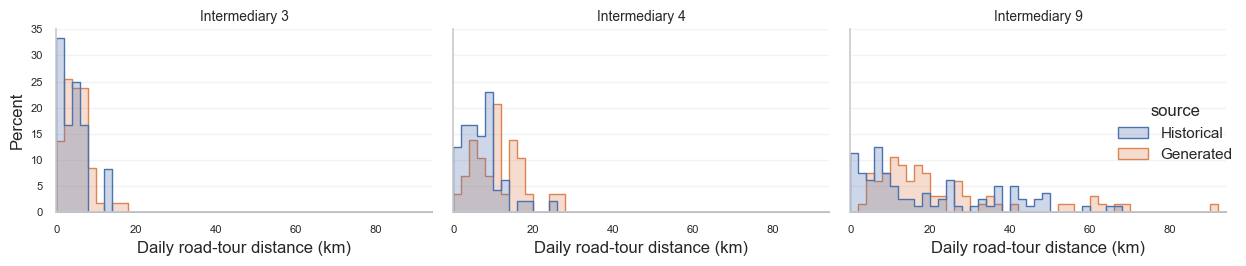

In [38]:
if RUN_ROAD_TSP:
    node_map = prepare_node_mapping([ig.farmers_full_df, df_gen], ig.G_proj)

    hist_data = ig.farmers_full_df.merge(node_map, on=["farmer_x", "farmer_y"], how="left")
    gen_data = df_gen.merge(node_map, on=["farmer_x", "farmer_y"], how="left")

    print("Starting TSP calculations for historical data...")
    road_hist = get_daily_tsp_dist(hist_data, ig.G_proj)
    road_hist["source"] = "Historical"

    print("Starting TSP calculations for generated data...")
    road_gen = get_daily_tsp_dist(gen_data, ig.G_proj)
    road_gen["source"] = "Generated"

    road_combined = pd.concat([road_hist, road_gen], ignore_index=True)

    max_km = float(road_combined["km"].quantile(0.995))
    road_bins = np.arange(0, np.ceil(max_km / 2) * 2 + 2, 2)

    g = facet_hist_compare_by_intermediary(
        road_combined[road_combined.int_id_anon.isin(selected)],
        "km",
        title=None,
        xlabel="Daily road-tour distance (km)",
        bins=road_bins,
        col_wrap=3,
        height=3,
        aspect=1.25,
        xlim=(0, road_bins.max()),
    )
    save_fig(g.figure, "daily_road_tour_distance_hist_vs_generated.png", dpi=300)
    plt.show()
else:
    print("Skipped road-tour diagnostic. Set RUN_ROAD_TSP = True to run it.")
